# Coding

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Data
hours = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
scores = [50, 60, 65, 70, 75, 80, 85, 95, 98, 100]

In [4]:
# Fungsi bantuan untuk menghitung mean dan standar deviasi (std)
def mean(values):
    return sum(values) / len(values)

def std(values):
    mean_val = mean(values)
    return (sum((x - mean_val) ** 2 for x in values) / len(values)) ** 0.5


In [5]:
# Menghitung rata-rata hours dan scores
mean_hours = mean(hours)
mean_scores = mean(scores)


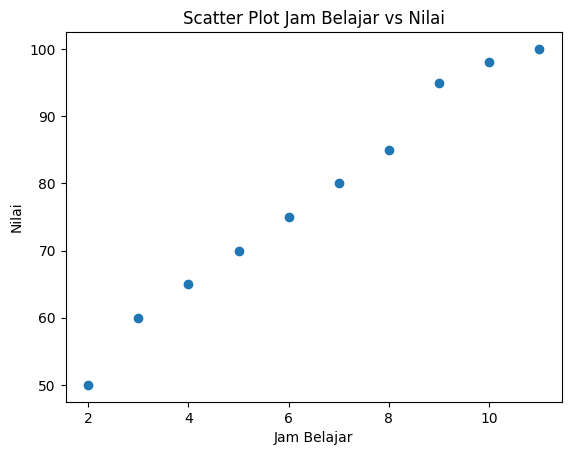

In [6]:

# Membuat scatter plot
plt.scatter(hours, scores)
plt.title('Scatter Plot Jam Belajar vs Nilai')
plt.xlabel('Jam Belajar')
plt.ylabel('Nilai')
plt.show()


In [7]:

# Menghitung korelasi
correlation = sum((x - mean_hours) * (y - mean_scores) for x, y in zip(hours, scores)) / (len(hours) * std(hours) * std(scores))

# Mencetak korelasi
print("Korelasi antara Jam Belajar dan Nilai:", correlation)


Korelasi antara Jam Belajar dan Nilai: 0.9935718888849912


In [8]:

# Menghitung koefisien regresi (slope dan intercept)
numerator = sum((x - mean_hours) * (y - mean_scores) for x, y in zip(hours, scores))
denominator = sum((x - mean_hours) ** 2 for x in hours)


In [9]:
# Menghitung slope dan intercept
slope = numerator / denominator
intercept = mean_scores - slope * mean_hours


In [10]:

# Fungsi untuk prediksi
def predict(x):
    return slope * x + intercept


In [11]:

# Mencetak hasil slope dan intercept
print("Slope (b1):", slope)
print("Intercept (b0):", intercept)


Slope (b1): 5.551515151515152
Intercept (b0): 41.71515151515151


In [12]:

# Fungsi untuk menghitung MAE, MSE, RMSE
def mae(predictions, targets):
    return sum(abs(p - t) for p, t in zip(predictions, targets)) / len(targets)

def mse(predictions, targets):
    return sum((p - t) ** 2 for p, t in zip(predictions, targets)) / len(targets)

def rmse(predictions, targets):
    return (mse(predictions, targets)) ** 0.5


In [13]:

# Membuat prediksi untuk setiap jam belajar
predictions = [predict(x) for x in hours]


In [14]:

# Menghitung MAE, MSE, dan RMSE
mae_value = mae(predictions, scores)
mse_value = mse(predictions, scores)
rmse_value = rmse(predictions, scores)


In [15]:

# Menghitung R-squared
sst = sum((y - mean_scores) ** 2 for y in scores)
ssr = sum((p - y) ** 2 for p, y in zip(predictions, scores))
r_squared_value = 1 - (ssr / sst)


In [16]:

# Mencetak hasil evaluasi
print("MAE:", mae_value)
print("MSE:", mse_value)
print("RMSE:", rmse_value)
print("R-squared:", r_squared_value)

MAE: 1.465454545454545
MSE: 3.3006060606060528
RMSE: 1.816757017491897
R-squared: 0.9871850983824894


In [17]:

# Menambahkan hasil prediksi dan residu ke dataset
dataset = {
    "Hours (x)": hours,
    "Scores (y)": scores,
    "Predicted Scores": predictions,
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               "Residu": [y - p for y, p in zip(scores, predictions)]
}


In [17]:

# Membuat DataFrame
df_dataset = pd.DataFrame(dataset)

# Mencetak DataFrame
print(df_dataset)

   Hours (x)  Scores (y)  Predicted Scores    Residu
0          2          50         52.818182 -2.818182
1          3          60         58.369697  1.630303
2          4          65         63.921212  1.078788
3          5          70         69.472727  0.527273
4          6          75         75.024242 -0.024242
5          7          80         80.575758 -0.575758
6          8          85         86.127273 -1.127273
7          9          95         91.678788  3.321212
8         10          98         97.230303  0.769697
9         11         100        102.781818 -2.781818
